# P2. Python for AI

**TARI29 Artificial Intelligence, 7.5 Credits**  
**Autumn 2026**  
**Lecturer:** Joel Scarinius Stävmo
**School of Engineering, Jönköping University**

## Learning goals

By the end of this notebook, you should be able to:

1. Represent facts and rules with relational logic.
2. Query family and geographic relationships.
3. Formulate and solve a finite-domain constraint satisfaction problem.
4. Implement an 8-puzzle solver using A* and Manhattan distance.
5. Normalize, tokenize, filter, chunk, and vectorize text.

> **Run order:** Execute cells from top to bottom. The setup cell installs the packages used in the lecture. A kernel restart may be required after first-time installation.


## 0. Environment setup

The maintained distribution named `miniKanren` still imports as `kanren`. The CSP example uses the modern `python-constraint2` distribution, which also imports as `constraint`.


In [2]:
# Uncomment and run once if the packages are not installed.
# %pip install --upgrade pip
# %pip install miniKanren simpleai python-constraint2 nltk gensim

In [3]:
# First run only: download the small NLTK resources needed below.
import nltk

for resource in ("punkt_tab", "averaged_perceptron_tagger_eng", "stopwords"):
    nltk.download(resource, quiet=True)

print("NLTK resources are ready.")

NLTK resources are ready.


# 1. Logic Programming

Logic programming represents knowledge as **facts** and **relations**, then asks an inference engine to find values satisfying one or more logical goals.

Typical applications include expert systems, natural-language processing, knowledge representation, and constraint solving.


## 1.1 Minimal logic-programming example

A relation stores tuples that are considered true. A logic variable is a placeholder whose possible values are discovered by `run`.


In [4]:
from kanren import Relation, facts, run, var

parent_demo = Relation()
# You can do this on one or several lines of code.
facts(parent_demo, ("John", "Mary"), ("John", "Tom"), ("Mary", "Ann"))

x = var()
run(0, x, parent_demo(x, "Mary"))

('John',)

The result contains every value of `x` that makes `parent_demo(x, "Mary")` true. Passing `0` as the first argument asks for all solutions.


## 1.2 Parsing a family tree

The tree is:

```text
David
├── John
│   ├── Tom
│   └── Ann
└── Mary
    ├── Joe
    └── Sue
```

David is therefore the grandparent of Tom, Ann, Joe, and Sue.

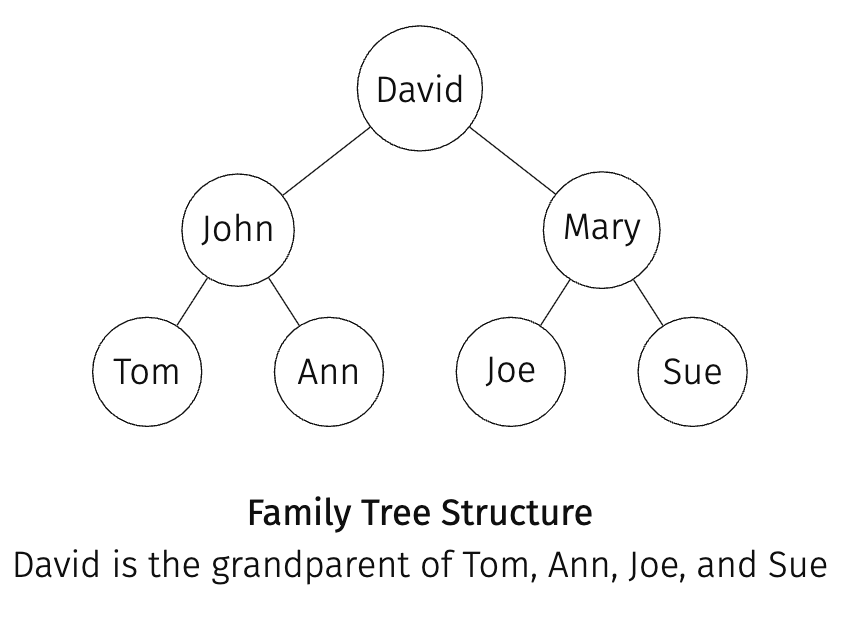

In [5]:
from kanren import Relation, facts, run, var, lall
from kanren.constraints import neq

parent = Relation()


# Here this is mashed into one facts call but can also be separated into many facts calls.
def load_family():
    facts(
        parent,
        ("David", "John"),
        ("David", "Mary"),
        ("John", "Tom"),
        ("John", "Ann"),
        ("Mary", "Joe"),
        ("Mary", "Sue"),
    )


load_family()

### Derived rules

- **Grandparent:** `gp` is a parent of an intermediate person `p`, and `p` is a parent of `gc`.
- **Sibling:** two different people share a parent.

Here, `grandparent_rule` is used directly as the derived relation.


In [ ]:
# lall means logical AND: it combines multiple goals into one goal that succeeds only when all of the supplied goals can be satisfied.


def grandparent_rule(gp, gc):
    p = var()
    return lall(parent(gp, p), parent(p, gc))


def sibling_rule(person_a, person_b):
    p = var()
    return lall(
        parent(p, person_a),
        parent(p, person_b),
        neq(person_a, person_b),
    )

### Family queries

`run(n, variable, goals...)` returns up to `n` answers. With `n=0`, it returns all answers. Result order may vary because facts are not guaranteed to be traversed in insertion order, so the checks below compare sets.


In [ ]:
child = var()
children_of_john = run(0, child, parent("John", child))
print("John's children:", children_of_john)

grandchild = var()
grandchildren_of_david = run(0, grandchild, grandparent_rule("David", grandchild))
print("David's grandchildren:", grandchildren_of_david)

sibling = var()
siblings_of_tom = run(0, sibling, sibling_rule("Tom", sibling))
print("Tom's siblings:", siblings_of_tom)

# assert is a Python statement used to check that something is true.
assert set(children_of_john) == {"Tom", "Ann"}
assert set(grandchildren_of_david) == {"Tom", "Ann", "Joe", "Sue"}
assert set(siblings_of_tom) == {"Ann"}

John's children: ('Tom', 'Ann')
David's grandchildren: ('Joe', 'Tom', 'Sue', 'Ann')
Tom's siblings: ('Ann',)


## 1.3 Analyzing geography

We model two kinds of facts:

- `adjacent(state_a, state_b)` records a directed adjacency fact.
- `coastal(state)` records a one-place property.

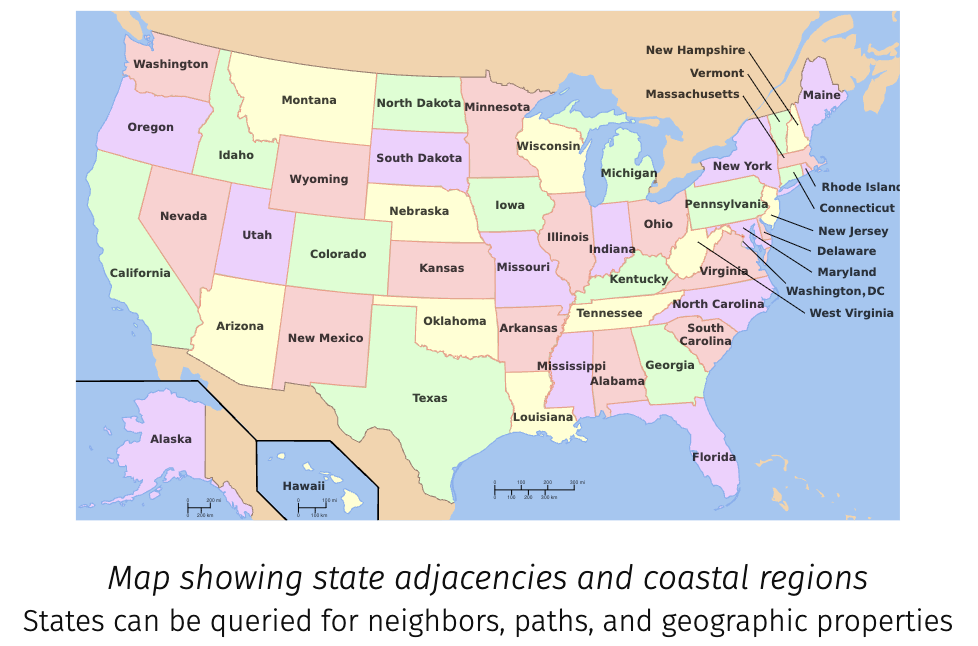

In [8]:
adjacent = Relation()
coastal = Relation()

facts(
    adjacent,
    ("California", "Oregon"),
    ("California", "Nevada"),
    ("California", "Arizona"),
    ("Oregon", "Nevada"),
    ("Oregon", "Washington"),
    ("Oregon", "Idaho"),
    ("Nevada", "Idaho"),
    ("Nevada", "Utah"),
    ("Nevada", "Arizona"),
)

facts(coastal, ("California",), ("Oregon",), ("Washington",))

neighbor, x, y = var(), var(), var()
coastal_neighbors = run(0, (x, y), adjacent(x, y), coastal(x), coastal(y))
print("Directed coastal-neighbor facts:", coastal_neighbors)
print("Neighbors of Oregon:", run(0, neighbor, adjacent("Oregon", neighbor)))

Directed coastal-neighbor facts: (('Oregon', 'Washington'), ('California', 'Oregon'))
Neighbors of Oregon: ('Idaho', 'Nevada', 'Washington')


### Symmetric adjacency

Instead of defining a recursive logic rule, this version loads both directions explicitly. That makes queries intuitive and avoids accidental infinite recursion in a cyclic graph.


In [9]:
adjacent_symmetric = Relation()
edges = [
    ("California", "Oregon"),
    ("California", "Nevada"),
    ("California", "Arizona"),
    ("Oregon", "Nevada"),
    ("Oregon", "Washington"),
    ("Oregon", "Idaho"),
    ("Nevada", "Idaho"),
    ("Nevada", "Utah"),
    ("Nevada", "Arizona"),
]
facts(adjacent_symmetric, *edges, *((b, a) for a, b in edges))

neighbor = var()
print("Neighbors of Oregon:", run(0, neighbor, adjacent_symmetric("Oregon", neighbor)))

Neighbors of Oregon: ('Idaho', 'Nevada', 'Washington', 'California')


# 2. Heuristic Search

Heuristic search uses domain knowledge to guide exploration. Examples include A*, greedy best-first search, hill climbing, and simulated annealing. Applications include navigation, puzzle solving, game AI, and optimization.


## 2.1 Constraint satisfaction: exam scheduling

A constraint satisfaction problem contains:

- **Variables:** CS, MATH, and AI exams.
- **Domains:** time slots 1 and 2.
- **Constraints:** CS must differ from MATH, and MATH must differ from AI.
- **Objective:** find every consistent assignment.


In [10]:
from constraint import Problem

problem = Problem()
problem.addVariables(["CS", "MATH", "AI"], [1, 2])
problem.addConstraint(lambda cs, math: cs != math, ("CS", "MATH"))
problem.addConstraint(lambda math, ai: math != ai, ("MATH", "AI"))

solutions = problem.getSolutions()
for i, solution in enumerate(solutions, start=1):
    print(f"Solution {i}: {solution}")

assert len(solutions) == 2

Solution 1: {'MATH': 2, 'CS': 1, 'AI': 1}
Solution 2: {'MATH': 1, 'CS': 2, 'AI': 2}


CS and AI may share a slot because no constraint says otherwise. MATH must be placed in the opposite slot from both.


## 2.2 Building an 8-puzzle solver

The 8-puzzle uses a 3 × 3 board. Eight numbered tiles move by sliding into a blank position represented by `0`.

**Initial state**

```text
1 2 3
4 _ 5
6 7 8
```

**Goal state**

```text
1 2 3
4 5 6
7 8 _
```

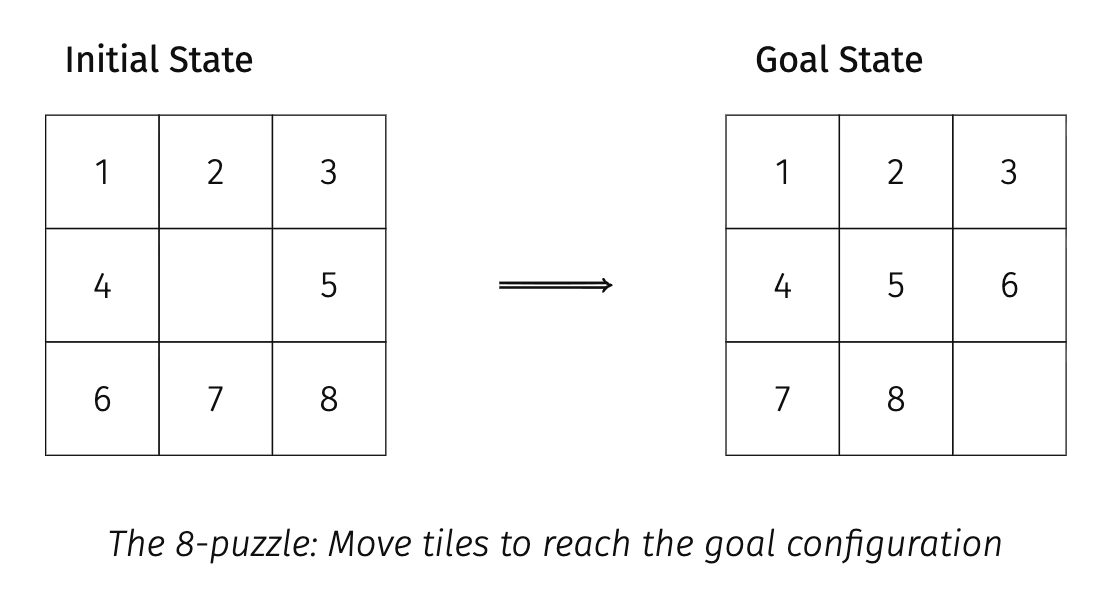

In [11]:
initial_state = (
    (1, 2, 3),
    (4, 0, 5),
    (6, 7, 8),
)

goal_state = (
    (1, 2, 3),
    (4, 5, 6),
    (7, 8, 0),
)

### Search-problem formulation

A search problem needs:

1. A state representation.
2. Valid actions from each state.
3. A result function that applies an action.
4. A goal test.
5. A path cost.
6. For A*, a heuristic estimating remaining cost.

The important idea is that A* doesn't need to know anything specifically about puzzles.

It just needs to be told:

- What is the current state?
- What actions can I take?
- What happens when I take an action?
- Is this the goal?
- What does an action cost?
- How promising is a state?

The EightPuzzle class provides exactly that information.

In [ ]:
from simpleai.search import SearchProblem, astar


class EightPuzzle(SearchProblem):
    goal = ((1, 2, 3), (4, 5, 6), (7, 8, 0))
    deltas = {
        "UP": (-1, 0),
        "DOWN": (1, 0),
        "LEFT": (0, -1),
        "RIGHT": (0, 1),
    }

    def __init__(self, initial_state):
        super().__init__(initial_state=initial_state)

    # static remove the need of self in the function. It also makes it possible to call the function inside the class by using self.find_empty()
    @staticmethod
    def find_empty(state):
        for i, row in enumerate(state):
            for j, value in enumerate(row):
                if value == 0:
                    return i, j
        raise ValueError("State contains no blank tile (0).")

    # Given the current state, tell the A* which moves are possible.
    def actions(self, state):
        i, j = self.find_empty(state)
        valid = []
        for action, (di, dj) in self.deltas.items():
            new_i, new_j = i + di, j + dj
            if 0 <= new_i < 3 and 0 <= new_j < 3:
                valid.append(action)
        return valid

    def result(self, state, action):
        if action not in self.deltas:
            raise ValueError(f"Unknown action: {action}")
        i, j = self.find_empty(state)
        di, dj = self.deltas[action]
        new_i, new_j = i + di, j + dj
        if not (0 <= new_i < 3 and 0 <= new_j < 3):
            raise ValueError(f"Illegal action {action} from blank position {(i, j)}")

        # converts the tuples into lists since tuples cannot be modified.
        new_state = [list(row) for row in state]
        new_state[i][j], new_state[new_i][new_j] = (
            new_state[new_i][new_j],
            new_state[i][j],
        )
        return tuple(tuple(row) for row in new_state)

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state, action, state2):
        return 1

    # tile:   1 2 3 4 5 6 7 8
    # index:  0 1 2 3 4 5 6 7
    # goal_i = index // 3
    # goal_j = index % 3
    # Admissible heuristic which means it never overestimates. the distance will always be exact or less which often is the case in this puzzle since it does not take into account that several tiles has to be moved to move a specific tile to its goal state.
    def heuristic(self, state):
        distance = 0
        for i in range(3):
            for j in range(3):
                value = state[i][j]
                if value != 0:
                    goal_i = (value - 1) // 3
                    goal_j = (value - 1) % 3
                    distance += abs(i - goal_i) + abs(j - goal_j)
        return distance

### Why Manhattan distance?

Tiles cannot move diagonally. For each numbered tile, Manhattan distance counts the minimum vertical and horizontal displacement to its goal location. The sum is an admissible lower bound because it does not count extra moves caused by interactions among tiles.


In [13]:
def show_board(state):
    for row in state:
        print(" ".join("_" if value == 0 else str(value) for value in row))
    print()


puzzle = EightPuzzle(initial_state)
print("Initial heuristic:", puzzle.heuristic(initial_state))
show_board(initial_state)

Initial heuristic: 6
1 2 3
4 _ 5
6 7 8



### Run A*

`result.path()` includes the initial state as its first entry, paired with `None`. Therefore, the number of moves is `len(path) - 1`, not `len(path)` as suggested by the slide.


In [14]:
result = astar(puzzle, graph_search=True)
path = result.path()

print(f"Moves: {len(path) - 1}")
for step, (action, state) in enumerate(path):
    label = "START" if action is None else action
    print(f"Step {step}: {label}")
    show_board(state)

assert path[-1][1] == goal_state

Moves: 14
Step 0: START
1 2 3
4 _ 5
6 7 8

Step 1: RIGHT
1 2 3
4 5 _
6 7 8

Step 2: DOWN
1 2 3
4 5 8
6 7 _

Step 3: LEFT
1 2 3
4 5 8
6 _ 7

Step 4: LEFT
1 2 3
4 5 8
_ 6 7

Step 5: UP
1 2 3
_ 5 8
4 6 7

Step 6: RIGHT
1 2 3
5 _ 8
4 6 7

Step 7: DOWN
1 2 3
5 6 8
4 _ 7

Step 8: RIGHT
1 2 3
5 6 8
4 7 _

Step 9: UP
1 2 3
5 6 _
4 7 8

Step 10: LEFT
1 2 3
5 _ 6
4 7 8

Step 11: LEFT
1 2 3
_ 5 6
4 7 8

Step 12: DOWN
1 2 3
4 5 6
_ 7 8

Step 13: RIGHT
1 2 3
4 5 6
7 _ 8

Step 14: RIGHT
1 2 3
4 5 6
7 8 _



# 3. Natural Language Processing

This section covers the lecture's preprocessing pipeline: normalization, tokenization, stopword filtering, chunking, and bag-of-words term frequencies.


<meta charset='utf-8'><html contenteditable="false"><head><meta content="text/html; charset=us-ascii" http-equiv="Content-Type"><style>
a {
    text-decoration: none;
    color: #464feb;
}
tr th, tr td {
    border: 1px solid #e6e6e6;
}
tr th {
    background-color: #f5f5f5;
}
</style></head><body><div><p><strong>NLP Pipeline</strong>:</p>
<p><span></span></p><div><span>Raw text</span><br></div><div><span>    ↓</span><br></div><div><span>Normalization</span><br></div><div><span>    ↓</span><br></div><div><span>Tokenization</span><br></div><div><span>    ↓</span><br></div><div><span>Stopword removal</span><br></div><div><span>    ↓</span><br></div><div><span>POS tagging</span><br></div><div><span>    ↓</span><br></div><div><span>Chunking</span><br></div><div><span>    ↓</span><br></div><div><span>Bag of Words / TF-IDF</span><br></div><div><span>    ↓</span><br></div><div><span>Machine Learning</span></div><p></p>
<p>The key message is:</p>
<blockquote>
<p>Computers cannot directly understand text. We must gradually transform text into a structured representation that algorithms can work with.</p>
</blockquote>
<hr>
<h1>What is NLP?</h1>
<p><strong>Natural Language Processing (NLP)</strong> is the branch of AI that deals with human language.</p>
<p>Examples:</p>
<ul>
<li>Machine translation</li>
<li>Spell checking</li>
<li>Chatbots</li>
<li>Sentiment analysis</li>
<li>Search engines</li>
<li>Speech recognition</li>
</ul>
<p>Example text:</p>
<p><span></span></p><div><span>The quick brown fox jumps over the lazy dog.</span></div><p></p>
<p>For humans this is easy.</p>
<p>For a computer it initially looks like:</p>
<p><span></span></p><div><span>84 104 101 32 113 ...</span></div><p></p>
<p>just characters.</p>
<p>NLP transforms text into useful structures.</p>
<hr>

## 3.2 Text normalization

Normalization reduces incidental variation in case, accents, punctuation, and whitespace. The slide uses NFKC normalization but expects `Café` to become `cafe`. NFKC alone does not remove the accent, so this corrected function additionally decomposes with NFKD and removes combining marks.


<h1>NLTK and Gensim</h1>
<h2>NLTK</h2>
<p>Natural Language Toolkit.</p>
<p>A Python library providing:</p>
<ul>
<li>tokenization</li>
<li>tagging</li>
<li>chunking</li>
<li>parsing</li>
<li>classification</li>
</ul>
<p>Think of NLTK as:</p>
<blockquote>
<p>A toolbox for classical NLP.</p>
</blockquote>
<hr>
<h2>Gensim</h2>
<p>Used for:</p>
<ul>
<li>Bag of Words</li>
<li>TF-IDF</li>
<li>Topic modelling</li>
<li>Word vectors</li>
</ul>
<p>Think of Gensim as:</p>
<blockquote>
<p>A toolbox for representing documents numerically.</p>
</blockquote>
<hr>
<h1>Normalization</h1>
<p>Common question:</p>
<blockquote>
<p>Why can't we just use the text?</p>
</blockquote>
<p>Because:</p>
<p><span></span></p><div><span>Dog</span><br></div><div><span>dog</span><br></div><div><span>DOG</span></div><p></p>
<p>mean the same thing but look different.</p>
<p>Similarly:</p>
<p><span></span></p><div><span>Café</span><br></div><div><span>Cafe</span><br></div><div></div><p></p>
<p>may be treated differently.</p>
<hr>
<h2>Goal</h2>
<p>Reduce unnecessary variation.</p>
<p>Example:</p>
<p><span></span></p><div><span>"Hello!!!"</span></div><p></p>
<p>↓</p>
<p><span></span></p><div><span>"hello"</span></div><p></p>
<hr>
<h2>NFKC Normalization</h2>
<p><span></span></p><div><span>unicodedata.normalize('NFKC', s)</span></div><p></p>
<p>Unicode contains many visually similar characters.</p>
<p>For example:</p>
<p><span></span></p><div><span>ＡＢＣ</span></div><p></p>
<p>(full-width)</p>
<p>becomes</p>
<p><span></span></p><div><span>ABC</span><br></div><div><span></span></div><p></p>
<p>(normal characters)</p>
<p>This creates consistency.</p>
<hr>
<h2>Lowercasing</h2>
<p><span></span></p><div><span>s = s.lower()</span></div><p></p>
<p>Example:</p>
<p><span></span></p><div><span>DOG → dog</span><br></div><div><span>Dog → dog</span></div><p></p>
<p>Now they match.</p>
<hr>
<h2>Regular Expressions</h2>
<p><span></span></p><div><span>re.sub(...)</span></div><p></p>
<p>means:</p>
<blockquote>
<p>Replace text matching a pattern.</p>
</blockquote>
<hr>
<p>This line:</p>
<p><span></span></p><div><span>re.sub(r"[^A-Za-z0-9 ]", " ", s)</span><br></div><p></p>
<p>means:</p>
<p>Remove everything that isn't:</p>
<ul>
<li>A-Z</li>
<li>a-z</li>
<li>0-9</li>
<li>space</li>
</ul>
<p>Example:</p>
<p><span></span></p><div><span>Wow!!! €3.00?</span></div><p></p>
<p>↓</p>
<p><span></span></p><div><span>Wow   3 00</span></div><p></p>
<hr>
<h2>Why normalize?</h2>
<p>Without normalization:</p>
<p><span></span></p><div><span>dog</span><br></div><div><span>dogs</span><br></div><div><span>Dog</span><br></div><div><span>DOG</span></div><p></p>
<p>become four different features.</p>
<p>With normalization:</p>
<p><span></span></p><div><span>dog</span></div><p></p>
<p>or at least fewer variations.</p>
<hr>

In [15]:
import re
import unicodedata


def normalize(text):
    text = unicodedata.normalize("NFKC", text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9 ]", " ", text)
    text = re.sub(r" +", " ", text).strip()
    return text


raw = "Café prices—Wow!!  €3.00?  Yes."
print(f"This is the raw text:\n{raw}")
normalized = normalize(raw)
print(f"This is the normalized text:\n{normalized}")
assert normalized == "cafe prices wow 3 00 yes"

This is the raw text:
Café prices—Wow!!  €3.00?  Yes.
This is the normalized text:
cafe prices wow 3 00 yes


This ASCII-oriented policy is useful for the lecture example, but it is not universally appropriate. For multilingual work, preserve letters outside `a-z` unless transliteration is part of the task.


## 3.2 Sentence and word tokenization

Tokenization first separates sentences, then separates each sentence into words. The example lowercases tokens and retains only tokens beginning with a word character.


<h1>Tokenization</h1>
<p>A <strong>token</strong> is a basic unit of text.</p>
<p>Often:</p>
<p><span></span></p><div><span>word = token</span></div><p></p>
<p>although tokens can be punctuation too.</p>
<p>Also Note:</p>
<blockquote>
<p>Numbers of tokens differ from language to language.</p>
</blockquote>
<hr>
<p>Example</p>
<p><span></span></p><div><span>I love NLP.</span></div><p></p>
<p>Sentence tokenization:</p>
<p><span></span></p><div><span>["I love NLP."]</span></div><p></p>
<p>Word tokenization:</p>
<p><span></span></p><div><span>["I","love","NLP","."]</span></div><p></p>
<hr>
<h2>Sentence tokenization</h2>
<p><span></span></p><div><span>sent_tokenize(text)</span></div><p></p>
<p>Input:</p>
<p><span></span></p><div><span>Hello world.</span><br></div><div><span>How are you?</span><br></div><div><span></span></div><p></p>
<p>Output:</p>
<p><span></span></p><div><span>[</span><br></div><div><span>  "Hello world.",</span><br></div><div><span>  "How are you?"</span><br></div><div><span>]</span></div><p></p>
<hr>
<h2>Word tokenization</h2>
<p><span></span></p><div><span>word_tokenize(sentence)</span></div><p></p>
<p>Input:</p>
<p><span></span></p><div><span>Hello world.</span></div><p></p>
<p>Output:</p>
<p><span></span></p><div><span>[</span><br></div><div><span>  'Hello',</span><br></div><div><span>  'world',</span><br></div><div><span>  '.'</span><br></div><div><span>]</span></div><p></p>
<hr>
<h2>Why tokenize?</h2>
<p>Machine learning generally works on:</p>
<p><span></span></p><div><span>words</span></div><p></p>
<p>not huge strings.</p>
<hr>

In [16]:
from nltk.tokenize import sent_tokenize, word_tokenize

text = """NLTK makes NLP practical.
Tokenize sentences. Then tokenize words!"""

sentences = sent_tokenize(text)
words = [
    [word.lower() for word in word_tokenize(sentence) if re.match(r"\w+", word)]
    for sentence in sentences
]

print(sentences)
print(words)

['NLTK makes NLP practical.', 'Tokenize sentences.', 'Then tokenize words!']
[['nltk', 'makes', 'nlp', 'practical'], ['tokenize', 'sentences'], ['then', 'tokenize', 'words']]


## 3.3 Stopwords

Stopwords are frequent function words such as *the*, *and*, and *to*. They are often removed for bag-of-words or TF-IDF features, but may matter when syntax, negation, or word order is important.



<h1>Stopwords</h1>
<p>Stopwords are very frequent words.</p>
<p>Examples:</p>
<p><span></span></p><div><span>the</span><br></div><div><span>a</span><br></div><div><span>an</span><br></div><div><span>is</span><br></div><div><span>are</span><br></div><div><span>to</span><br></div><div><span>of</span><br></div><div><span>and</span></div><p></p>
<hr>
<p>Sentence:</p>
<p><span></span></p><div><span>This is a small example with some stopwords.</span></div><p></p>
<p>After removing stopwords:</p>
<p><span></span></p><div><span>small</span><br></div><div><span>example</span><br></div><div><span>stopwords</span></div><p></p>
<hr>
<h2>Why remove them?</h2>
<p>Because they carry little meaning.</p>
<p>Consider:</p>
<p><span></span></p><div><span>the</span><br></div><div><span>the</span><br></div><div><span>the</span><br></div><div><span>the</span></div><p></p>
<p>This tells us very little about the topic.</p>
<hr>
<h2>When NOT to remove stopwords?</h2>
<p>Don't blindly remove them.</p>
<p>Example sentiment analysis:</p>
<p><span></span></p><div><span>I like it</span><br></div><div></div><p></p>
<p>versus</p>
<p><span></span></p><div><span>I do not like it</span><br></div><div></div><p></p>
<p>If we remove</p>
<p><span></span></p><div><span>not</span></div><p></p>
<p>we destroy the meaning.</p>
<p>So stopword removal depends on the task.</p>
<hr>
<h1>6. POS Tagging</h1>
<p>POS = Part Of Speech</p>
<p>Words receive grammatical labels.</p>
<p>Example:</p>
<p><span></span></p><div><span>The quick brown fox jumps</span></div><p></p>
<p>becomes:</p>
<p><span></span></p><div><span>The     DT</span><br></div><div><span>quick   JJ</span><br></div><div><span>brown   JJ</span><br></div><div><span>fox     NN</span><br></div><div><span>jumps   VBZ</span><br></div><div><span></span></div><p></p>
<hr>
<p>Common tags</p>

































<table><thead><tr><th>Tag</th><th>Meaning</th></tr></thead><tbody><tr><td>DT</td><td>Determiner</td></tr><tr><td>JJ</td><td>Adjective</td></tr><tr><td>NN</td><td>Noun</td></tr><tr><td>NNS</td><td>Plural noun</td></tr><tr><td>VB</td><td>Verb</td></tr><tr><td>VBZ</td><td>Verb, third-person singular</td></tr></tbody></table>
<p>Example:</p>
<p><span></span></p><div><span>The dog runs.</span></div><p></p>
<p>↓</p>
<p><span></span></p><div><span>The/DT</span><br></div><div><span>dog/NN</span><br></div><div><span>runs/VBZ</span></div><p></p>
<hr>

In [17]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


def tokenize_no_stop(text):
    tokens = [word.lower() for word in word_tokenize(text)]
    print(tokens)
    # (method) def isalnum() -> bool
    # Return True if the string is an alpha-numeric string, False otherwise.
    # A string is alpha-numeric if all characters in the string are alpha-numeric and there is at least one character in the string.
    tokens = [token for token in tokens if token.isalnum()]
    print(tokens)
    english_stops = set(stopwords.words("english"))
    print(f"English stopwords:\n{english_stops}\n")
    return [token for token in tokens if token not in english_stops]


filtered = tokenize_no_stop("This is a small example, with some stopwords.")
print(filtered)
assert filtered == ["small", "example", "stopwords"]

['this', 'is', 'a', 'small', 'example', ',', 'with', 'some', 'stopwords', '.']
['this', 'is', 'a', 'small', 'example', 'with', 'some', 'stopwords']
English stopwords:
{"it's", 'weren', 'about', 'do', 'in', "wouldn't", 'against', 'herself', "she'd", 'have', 'nor', "you'd", 'did', 'our', 'theirs', 'these', 'i', 'he', "they're", 'than', 'we', 'were', 'you', "we'll", 'other', 'having', 's', "he's", "it'll", 'over', 'myself', 'hasn', 'wasn', 'couldn', 'each', 'she', 'up', 'll', 'had', 'a', 'below', 'will', "wasn't", "hadn't", 'this', 'doing', 't', 'wouldn', "you've", "needn't", 'its', "she's", 'how', 'the', 'him', "he'd", 'until', 'of', 'should', 'are', 'haven', 'isn', 'am', 'their', 'don', 'for', 'hers', 'too', "i'll", 'does', 'no', 'd', 'them', 'her', 'just', 'after', 'o', 'once', 'not', 'what', 'be', 'both', 'to', "didn't", "we've", 'between', 'before', 're', 'who', 'more', "i'm", 'there', 'those', 'during', 'doesn', 'ours', 'most', 'it', 'off', "you'll", 'that', 'an', 'where', 'my', 'hi

## 3.4 Chunking

Chunking is shallow parsing. The workflow is:

1. Tokenize.
2. Assign part-of-speech tags.
3. Apply a regular-expression grammar.

The grammar below finds noun phrases with an optional determiner, zero or more adjectives, and one or more singular or plural common nouns.



<h1>Chunking</h1>
<p>Chunking combines related words.</p>
<p>Also called:</p>
<p><span></span></p><div><span>Shallow Parsing</span><br></div><div></div><p></p>
<p>because it doesn't build a complete grammar tree.</p>
<hr>
<p>Example</p>
<p><span></span></p><div><span>The quick brown fox</span></div><p></p>
<p>We want:</p>
<p><span></span></p><div><span>[Noun Phrase]</span></div><p></p>
<p>instead of four separate words.</p>
<hr>
<h2>What is a noun phrase?</h2>
<p>A group of words centered around a noun.</p>
<p>Examples:</p>
<p><span></span></p><div><span>the dog</span><br></div><div><span>the red car</span><br></div><div><span>a very large building</span><br></div><div><span></span></div><p></p>
<hr>
<h1>Understanding the grammar</h1>
<p>You have:</p>
<p><span></span></p><div><span>grammar = r"NP: {&lt;DT&gt;?&lt;JJ&gt;*&lt;NN|NNS&gt;+}"</span></div><p></p>
<p>This means:</p>
<h3>NP</h3>
<p><span></span></p><div><span>NP = Noun Phrase</span></div><p></p>
<hr>
<h3><code>&lt;DT&gt;?</code></h3>
<p>Optional determiner.</p>
<p>Examples:</p>
<p><span></span></p><div><span>the</span><br></div><div><span>a</span><br></div><div><span>an</span></div><p></p>
<p>Question mark means:</p>
<p><span></span></p><div><span>0 or 1 occurrences</span></div><p></p>
<hr>
<h3><code>&lt;JJ&gt;*</code></h3>
<p>Zero or more adjectives.</p>
<p>Examples:</p>
<p><span></span></p><div><span>quick</span><br></div><div><span>brown</span><br></div><div><span>beautiful</span></div><p></p>
<p>Asterisk means:</p>
<p><span></span></p><div><span>0,1,2,3,...</span></div><p></p>
<hr>
<h3><code>&lt;NN|NNS&gt;+</code></h3>
<p>One or more nouns.</p>
<p>Examples:</p>
<p><span></span></p><div><span>dog</span><br></div><div><span>dogs</span><br></div><div><span>car</span><br></div><div><span>cars</span></div><p></p>
<p>Plus means:</p>
<p><span></span></p><div><span>at least one</span></div><p></p>
<hr>
<p>Entire rule:</p>
<p><span></span></p><div><span>(Optional determiner)</span><br></div><div><span>+</span><br></div><div><span>(Any number of adjectives)</span><br></div><div><span>+</span><br></div><div><span>(One or more nouns)</span></div><p></p>
<p>Matches:</p>
<p><span></span></p><div><span>the lazy dog</span><br></div><div><span>a red car</span><br></div><div><span>beautiful flowers</span></div><p></p>
<hr>
<h1>What does chunking produce?</h1>
<p>Input:</p>
<p><span></span></p><div><span>The quick brown fox jumps over the lazy dog</span></div><p></p>
<p>Output:</p>
<p><span></span></p><div><span>(NP The quick brown fox)</span><br></div><div><span>jumps</span><br></div><div><span>over</span><br></div><div><span>(NP the lazy dog)</span></div><p></p>
<p>The algorithm found two noun phrases.</p>
<hr>

In [18]:
from nltk import pos_tag, RegexpParser
from nltk.tokenize import word_tokenize

sentence = "The quick brown fox jumps over the lazy dog"
tokens = word_tokenize(sentence)
print(f"Tokens:\n{tokens}\n")
tags = pos_tag(tokens)
print(f"Tags:\n{tags}\n")

grammar = r"NP: {<DT>?<JJ>*<NN|NNS>+}"
print(f"Grammar:\n{grammar}\n")

chunker = RegexpParser(grammar)
chunk_tree = chunker.parse(tags)
print(f"Chunk Tree:\n{chunk_tree}\n")

chunk_tree.pretty_print()

Tokens:
['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

Tags:
[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN')]

Grammar:
NP: {<DT>?<JJ>*<NN|NNS>+}

Chunk Tree:
(S
  (NP The/DT quick/JJ brown/NN fox/NN)
  jumps/VBZ
  over/IN
  (NP the/DT lazy/JJ dog/NN))

                                     S                                 
     ________________________________|______________________            
    |        |              NP                              NP         
    |        |       _______|________________        _______|______     
jumps/VBZ over/IN The/DT quick/JJ brown/NN fox/NN the/DT lazy/JJ dog/NN



Expected structure, subject to the tagger version:

```text
(S
  (NP The/DT quick/JJ brown/NN fox/NN)
  jumps/VBZ
  over/IN
  (NP the/DT lazy/JJ dog/NN))
```


## 3.5 Bag of words: term frequencies

A Gensim `Dictionary` maps normalized tokens to integer IDs. `doc2bow` converts a tokenized document to sparse `(term_id, count)` pairs. Word order is discarded.


<h1>Bag of Words (BoW)</h1>
<p>This is one of the most important concepts.</p>
<p>Suppose we have:</p>
<p><span></span></p><div><span>cats like milk</span><br></div><div><span>dogs like bones</span><br></div><div><span>cats and dogs</span></div><p></p>
<hr>
<h2>Step 1: Build a vocabulary</h2>
<p>The computer collects all unique words.</p>
<p><span></span></p><div><span>cats</span><br></div><div><span>like</span><br></div><div><span>milk</span><br></div><div><span>dogs</span><br></div><div><span>bones</span><br></div><div><span>and</span></div><p></p>
<hr>
<p>Assign IDs:</p>
<p><span></span></p><div><span>{</span><br></div><div><span> 'cats':0,</span><br></div><div><span> 'like':1,</span><br></div><div><span> 'milk':2,</span><br></div><div><span> 'bones':3,</span><br></div><div><span> 'dogs':4,</span><br></div><div><span> 'and':5</span><br></div><div><span>}</span></div><p></p>
<hr>
<h2>Step 2: Count occurrences</h2>
<p>Document:</p>
<p><span></span></p><div><span>cats like milk</span></div><p></p>
<p>contains:</p>
<p><span></span></p><div><span>cats = 1</span><br></div><div><span>like = 1</span><br></div><div><span>milk = 1</span></div><p></p>
<p>Representation:</p>
<p><span></span></p><div><span>[(0,1),(1,1),(2,1)]</span></div><p></p>
<p>Meaning:</p>
<p><span></span></p><div><span>word 0 appears 1 time</span><br></div><div><span>word 1 appears 1 time</span><br></div><div><span>word 2 appears 1 time</span><br></div><div></div><p></p>
<hr>
<h1>Why is it called "Bag" of Words?</h1>
<p>Because order is ignored.</p>
<p>These two become identical:</p>
<p><span></span></p><div><span>dogs like cats</span></div><p></p>
<p>and</p>
<p><span></span></p><div><span>cats like dogs</span></div><p></p>
<p>The model only sees counts.</p>
<p>Like throwing words into a bag.</p>
<hr>
<h1>Sparse Vector</h1>
<p>Suppose vocabulary contains:</p>
<p><span></span></p><div><span>10000 words</span></div><p></p>
<p>but one document uses:</p>
<p><span></span></p><div><span>20 words</span></div><p></p>
<p>Most positions are:</p>
<p><span></span></p><div><span>0</span><br></div><div><span></span></div><p></p>
<p>So storing</p>
<p><span></span></p><div><span>[0,0,0,0,0,...]</span></div><p></p>
<p>wastes memory.</p>
<p>Instead store only:</p>
<p><span></span></p><div><span>[(word_id,count)]</span></div><p></p>
<p>This is called a <strong>sparse representation</strong>.</p>
<hr>
<h1>TF-IDF</h1>
<h2>TF</h2>
<p>Term Frequency</p>
<p><span></span></p><div><span>How often a word appears in a document.</span><br></div><div></div><p></p>
<hr>
<h2>IDF</h2>
<p>Inverse Document Frequency</p>
<p><span></span></p><div><span>How rare the word is across all documents.</span></div><p></p>
<hr>
<p>Words like:</p>
<p><span></span></p><div><span>the</span><br></div><div><span>and</span><br></div><div><span>is</span></div><p></p>
<p>appear everywhere.</p>
<p>Therefore:</p>
<p><span></span></p><div><span>low IDF</span></div><p></p>
<p>Rare topic-specific words:</p>
<p><span></span></p><div><span>algorithm</span><br></div><div><span>neural</span><br></div><div><span>genome</span></div><p></p>
<p>have:</p>
<p><span></span></p><div><span>high IDF</span></div><p></p>
<hr>
<p>TF-IDF rewards words that are:</p>
<p><span></span></p><div><span>frequent in this document</span><br></div><div><span>rare in the whole collection</span><br></div><div><span></span></div><p></p>
<p>which makes them more informative.</p>
<hr>

In [19]:
from gensim.corpora import Dictionary

corpus_texts = [
    "cats like milk",
    "dogs like bones",
    "cats and dogs",
]

docs = [text.split() for text in corpus_texts]
dictionary = Dictionary(docs)
bow = [dictionary.doc2bow(doc) for doc in docs]

print("The docs:")
print(docs)
print("The dictionary with term IDs:")
print(dictionary.token2id)
print("The bag of words for each doc:")
print(bow)

The docs:
[['cats', 'like', 'milk'], ['dogs', 'like', 'bones'], ['cats', 'and', 'dogs']]
The dictionary with term IDs:
{'cats': 0, 'like': 1, 'milk': 2, 'bones': 3, 'dogs': 4, 'and': 5}
The bag of words for each doc:
[[(0, 1), (1, 1), (2, 1)], [(1, 1), (3, 1), (4, 1)], [(0, 1), (4, 1), (5, 1)]]


In [20]:
# Decode the sparse vectors to make them easier to read.
decoded_bow = [
    [(dictionary[term_id], count) for term_id, count in document] for document in bow
]
for i, document in enumerate(decoded_bow, start=1):
    print(f"Document {i}: {document}")

Document 1: [('cats', 1), ('like', 1), ('milk', 1)]
Document 2: [('like', 1), ('bones', 1), ('dogs', 1)]
Document 3: [('cats', 1), ('dogs', 1), ('and', 1)]


# 4. Optional material

## 4.2 Three-variable all-different CSP

Demonstrates a small map-coloring-style constraint problem with three values.


In [21]:
from constraint import AllDifferentConstraint

coloring = Problem()
coloring.addVariables(["A", "B", "C"], [1, 2, 3])
coloring.addConstraint(AllDifferentConstraint(), ["A", "B", "C"])
coloring_solutions = coloring.getSolutions()

print("Number of solutions:", len(coloring_solutions))
print("One solution:", coloring_solutions[0])
assert len(coloring_solutions) == 6

Number of solutions: 6
One solution: {'A': 3, 'B': 2, 'C': 1}


## 4.3 Small Naive Bayes category predictor

With only six labeled sentences, its train/test accuracy is unstable and should be treated as a mechanics demonstration rather than a meaningful evaluation.


In [22]:
import random
import nltk

labeled = [
    ("I love this phone", "pos"),
    ("Amazing battery life", "pos"),
    ("Worst camera ever", "neg"),
    ("The screen is awful", "neg"),
    ("Great price and quality", "pos"),
    ("Terrible performance", "neg"),
]

all_words = nltk.FreqDist(
    word.lower() for sentence, _ in labeled for word in sentence.split()
)
feature_words = list(all_words)[:200]


def featurize(sentence):
    words_in_sentence = set(sentence.lower().split())
    return {word: word in words_in_sentence for word in feature_words}


dataset = [(featurize(sentence), category) for sentence, category in labeled]
random.Random(42).shuffle(dataset)
cut = max(1, int(0.7 * len(dataset)))
train, test = dataset[:cut], dataset[cut:]

classifier = nltk.NaiveBayesClassifier.train(train)
print("Toy test accuracy:", nltk.classify.accuracy(classifier, test))
classifier.show_most_informative_features(10)

Toy test accuracy: 0.0
Most Informative Features
                 amazing = False             neg : pos    =      1.7 : 1.0
                     and = False             neg : pos    =      1.7 : 1.0
                   awful = False             pos : neg    =      1.7 : 1.0
                 battery = False             neg : pos    =      1.7 : 1.0
                  camera = False             pos : neg    =      1.7 : 1.0
                    ever = False             pos : neg    =      1.7 : 1.0
                   great = False             neg : pos    =      1.7 : 1.0
                      is = False             pos : neg    =      1.7 : 1.0
                    life = False             neg : pos    =      1.7 : 1.0
                   price = False             neg : pos    =      1.7 : 1.0


<blockquote>
<p>The classifier isn't broken. The dataset is too small. Machine learning algorithms need enough examples to discover patterns. With only four training sentences, the model cannot reliably learn what makes a review positive or negative.</p>
</blockquote>
<p><strong>Quality and quantity of training data matter just as much as the algorithm itself.</strong></p></div></body></html>

# 5. Five things to remember:

1. Normalization = make text consistent.
2. Tokenization = split text into tokens.
3. Stopwords = common words often removed.
4. POS tagging + Chunking = discover grammatical structure.
5. Bag of Words / TF-IDF = convert text into numbers for machine learning.

# 6. Literature and package references

The lecture cites:

- Alberto Artasanchez and Prateek Joshi, *Artificial Intelligence with Python*, 2nd edition, Packt Publishing, 2020.

Useful package documentation:

- [miniKanren on PyPI](https://pypi.org/project/miniKanren/)
- [SimpleAI search problems](https://simpleai.readthedocs.io/en/latest/search_problems.html)
- [python-constraint2 on PyPI](https://pypi.org/project/python-constraint2/)
- [Installing NLTK data](https://www.nltk.org/data.html)
- [Gensim Dictionary API](https://radimrehurek.com/gensim/corpora/dictionary.html)
